# Project 01 — UK Road Safety Analysis
## Notebook 1: Data Profiling & Initial Inspection

**Dataset:** STATS19 — DfT Road Safety Data (last 5 years)  
**DDaT Competency:** Applied maths · Data engineering · Data ethics  
**Notebook goal:** Load all three datasets, understand their structure,
assess data quality, and document initial findings.

---

In [5]:
# Standard library
import os

print("Current working directory:")
print(os.getcwd())

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print("All imports successful ✓")

Current working directory:
C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project1
All imports successful ✓


## 1. Loading the Data

We load all three STATS19 tables separately. Each table represents
a different unit of analysis:

- **Collision** — one row per accident (location, time, conditions)
- **Vehicle** — one row per vehicle involved in an accident
- **Casualty** — one row per person injured or killed

These three tables are linked by a common key: `accident_index`

In [8]:
# Build absolute path — works regardless of where Jupyter is launched from
project_root = r'C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project1'
data_path = os.path.join(project_root, 'data', 'raw')

# Verify the path exists before loading
print(f"Looking for data in:\n{data_path}\n")
print(f"Files found: {os.listdir(data_path)}\n")

# Load all three datasets
print("Loading datasets... this may take a moment due to file size.\n")

collisions = pd.read_csv(
    os.path.join(data_path, 'dft-road-casualty-statistics-collision-last-5-years.csv'),
    low_memory=False
)

vehicles = pd.read_csv(
    os.path.join(data_path, 'dft-road-casualty-statistics-vehicle-last-5-years.csv'),
    low_memory=False
)

casualties = pd.read_csv(
    os.path.join(data_path, 'dft-road-casualty-statistics-casualty-last-5-years.csv'),
    low_memory=False
)

print(f"✓ Collisions table:  {collisions.shape[0]:,} rows × {collisions.shape[1]} columns")
print(f"✓ Vehicles table:    {vehicles.shape[0]:,} rows × {vehicles.shape[1]} columns")
print(f"✓ Casualties table:  {casualties.shape[0]:,} rows × {casualties.shape[1]} columns")

Looking for data in:
C:\Users\TEST\OneDrive\Documents\The United Kingdom\Jobs\Data Science\portfolio\project1\data\raw

Files found: ['dft-road-casualty-statistics-casualty-last-5-years.csv', 'dft-road-casualty-statistics-collision-last-5-years.csv', 'dft-road-casualty-statistics-vehicle-last-5-years.csv']

Loading datasets... this may take a moment due to file size.

✓ Collisions table:  503,475 rows × 44 columns
✓ Vehicles table:    920,692 rows × 32 columns
✓ Casualties table:  640,522 rows × 23 columns


## 2. Data Profiling

Before any analysis, we must understand what we have.
Data profiling answers four questions:
- What are the columns and their data types?
- How many missing values are there?
- What do the basic statistics look like?
- Are there any immediate quality concerns?

In [9]:
def profile_dataframe(df, name):
    """
    Produces a concise profile of a DataFrame.
    Shows shape, dtypes, missing values and basic stats.
    
    Parameters
    ----------
    df   : pd.DataFrame
    name : str — label for display
    """
    print("=" * 60)
    print(f"  PROFILE: {name}")
    print("=" * 60)
    
    print(f"\n Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    
    print(f"\n{'Column':<45} {'Dtype':<12} {'Missing':>8} {'Missing %':>10}")
    print("-" * 78)
    
    for col in df.columns:
        missing       = df[col].isna().sum()
        missing_pct   = (missing / len(df)) * 100
        dtype         = str(df[col].dtype)
        print(f"  {col:<43} {dtype:<12} {missing:>8,} {missing_pct:>9.1f}%")
    
    print("=" * 60)
    print()

# Profile all three datasets
profile_dataframe(collisions, "COLLISIONS")
profile_dataframe(vehicles,   "VEHICLES")
profile_dataframe(casualties, "CASUALTIES")

  PROFILE: COLLISIONS

 Shape: 503,475 rows × 44 columns

Column                                        Dtype         Missing  Missing %
------------------------------------------------------------------------------
  collision_index                             str                 0       0.0%
  collision_year                              int64               0       0.0%
  collision_ref_no                            str                 0       0.0%
  location_easting_osgr                       float64            65       0.0%
  location_northing_osgr                      float64            65       0.0%
  longitude                                   float64            65       0.0%
  latitude                                    float64            65       0.0%
  police_force                                int64               0       0.0%
  collision_severity                          int64               0       0.0%
  number_of_vehicles                          int64               0      

## 3. Decoding Categorical Variables

Most columns are stored as integer codes.
We map these to human-readable labels using the
official DfT lookup definitions before any analysis.

In [10]:
# Official DfT label mappings
# Source: STATS19 data guide — Road Safety Open Data

severity_labels = {
    1: 'Fatal',
    2: 'Serious', 
    3: 'Slight'
}

day_labels = {
    1: 'Sunday',
    2: 'Monday',
    3: 'Tuesday',
    4: 'Wednesday',
    5: 'Thursday',
    6: 'Friday',
    7: 'Saturday'
}

weather_labels = {
    1:  'Fine — no high winds',
    2:  'Raining — no high winds',
    3:  'Snowing — no high winds',
    4:  'Fine + high winds',
    5:  'Raining + high winds',
    6:  'Fog or mist',
    7:  'Other',
    8:  'Unknown',
    9:  'Fine + no high winds',   # legacy code
    -1: 'Data missing'
}

road_surface_labels = {
    1:  'Dry',
    2:  'Wet or damp',
    3:  'Snow',
    4:  'Frost or ice',
    5:  'Flood over 3cm deep',
    6:  'Oil or diesel',
    7:  'Mud',
    -1: 'Data missing'
}

light_labels = {
    1:  'Daylight',
    4:  'Darkness — lights lit',
    5:  'Darkness — lights unlit',
    6:  'Darkness — no lighting',
    7:  'Darkness — lighting unknown',
    -1: 'Data missing'
}

urban_rural_labels = {
    1: 'Urban',
    2: 'Rural',
    3: 'Unallocated'
}

speed_limit_labels = {
    20:  '20 mph',
    30:  '30 mph',
    40:  '40 mph',
    50:  '50 mph',
    60:  '60 mph',
    70:  '70 mph',
    99:  'Unknown',
    -1:  'Data missing'
}

# Apply mappings to create new readable columns
collisions['severity']      = collisions['collision_severity'].map(severity_labels)
collisions['day_name']      = collisions['day_of_week'].map(day_labels)
collisions['weather']       = collisions['weather_conditions'].map(weather_labels)
collisions['road_surface']  = collisions['road_surface_conditions'].map(road_surface_labels)
collisions['light']         = collisions['light_conditions'].map(light_labels)
collisions['area_type']     = collisions['urban_or_rural_area'].map(urban_rural_labels)
collisions['speed_lim']     = collisions['speed_limit'].map(speed_limit_labels)

# Verify — show value counts for severity
print("Collision severity distribution:")
print("-" * 35)
print(collisions['severity'].value_counts())
print(f"\nTotal collisions: {len(collisions):,}")

Collision severity distribution:
-----------------------------------
severity
Slight     386007
Serious    109977
Fatal        7491
Name: count, dtype: int64

Total collisions: 503,475


In [11]:
# Calculate percentage breakdown — this is descriptive statistics in action
severity_counts = collisions['severity'].value_counts()
severity_pct    = (severity_counts / len(collisions) * 100).round(2)

print("Collision Severity Breakdown — Great Britain (last 5 years)")
print("=" * 55)
for severity, count in severity_counts.items():
    pct = severity_pct[severity]
    bar = '█' * int(pct / 2)
    print(f"  {severity:<10} {count:>8,}  ({pct:>5.1f}%)  {bar}")
print("=" * 55)
print(f"  {'TOTAL':<10} {len(collisions):>8,}  (100.0%)")

# Annual averages
years = collisions['collision_year'].nunique()
print(f"\n  Data spans {years} years")
print(f"  Average per year:")
for severity, count in severity_counts.items():
    print(f"    {severity:<10} {count//years:>6,} per year")

Collision Severity Breakdown — Great Britain (last 5 years)
  Slight      386,007  ( 76.7%)  ██████████████████████████████████████
  Serious     109,977  ( 21.8%)  ██████████
  Fatal         7,491  (  1.5%)  
  TOTAL       503,475  (100.0%)

  Data spans 5 years
  Average per year:
    Slight     77,201 per year
    Serious    21,995 per year
    Fatal       1,498 per year


In [12]:
# Parse date and extract time features
collisions['date']  = pd.to_datetime(collisions['date'], dayfirst=True)
collisions['year']  = collisions['date'].dt.year
collisions['month'] = collisions['date'].dt.month
collisions['month_name'] = collisions['date'].dt.strftime('%B')

# Parse hour from time column (format is HH:MM)
collisions['hour'] = pd.to_numeric(
    collisions['time'].str.split(':').str[0],
    errors='coerce'
)

print("Date and time features extracted ✓")
print(f"\nYears in dataset:  {sorted(collisions['year'].unique())}")
print(f"Hours range:       {collisions['hour'].min()} to {collisions['hour'].max()}")
print(f"Missing hours:     {collisions['hour'].isna().sum()}")

Date and time features extracted ✓

Years in dataset:  [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]
Hours range:       0 to 23
Missing hours:     0


## 4. Exploratory Visualisations

Each chart answers a specific analytical question.
We follow the principle: one chart, one question.

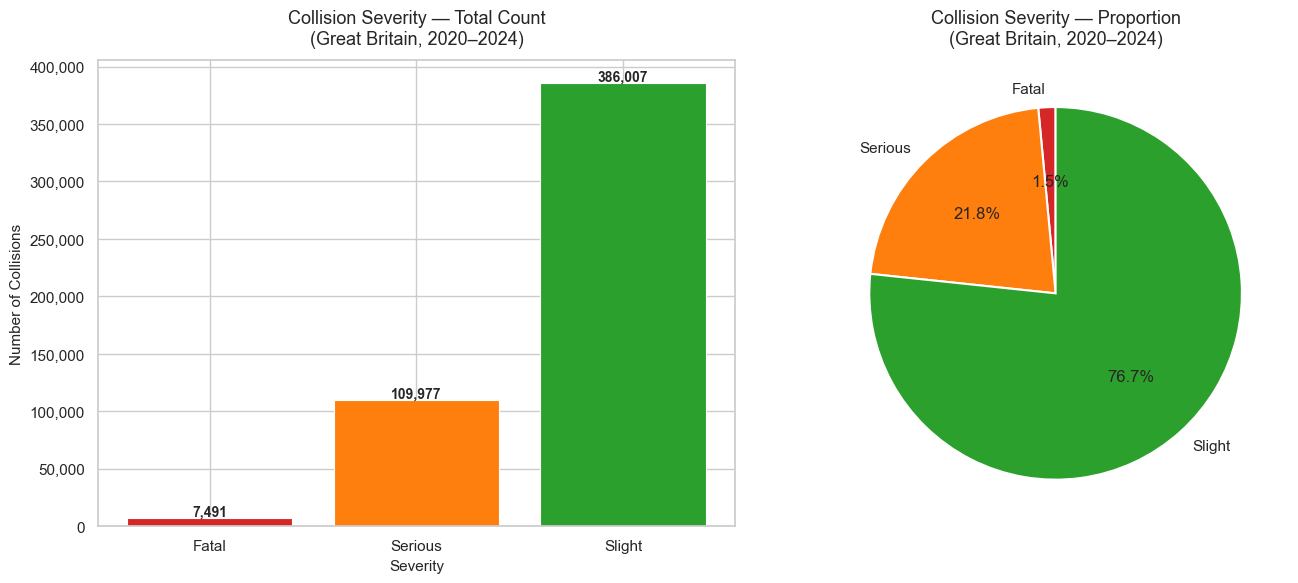

Chart saved ✓


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left chart: bar chart of counts ---
severity_order  = ['Fatal', 'Serious', 'Slight']
severity_counts = collisions['severity'].value_counts().reindex(severity_order)
colours         = ['#d62728', '#ff7f0e', '#2ca02c']

axes[0].bar(severity_order, severity_counts.values, color=colours, 
            edgecolor='white', linewidth=0.8)
axes[0].set_title('Collision Severity — Total Count\n(Great Britain, 2020–2024)', 
                   fontsize=13, pad=12)
axes[0].set_xlabel('Severity', fontsize=11)
axes[0].set_ylabel('Number of Collisions', fontsize=11)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}')
)
for i, (val, colour) in enumerate(zip(severity_counts.values, colours)):
    axes[0].text(i, val + 2000, f'{val:,}', ha='center', 
                 fontsize=10, fontweight='bold')

# --- Right chart: pie chart of proportions ---
axes[1].pie(
    severity_counts.values,
    labels=severity_order,
    colors=colours,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Collision Severity — Proportion\n(Great Britain, 2020–2024)', 
                   fontsize=13, pad=12)

plt.tight_layout()
plt.savefig('outputs/figures/01_severity_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✓")

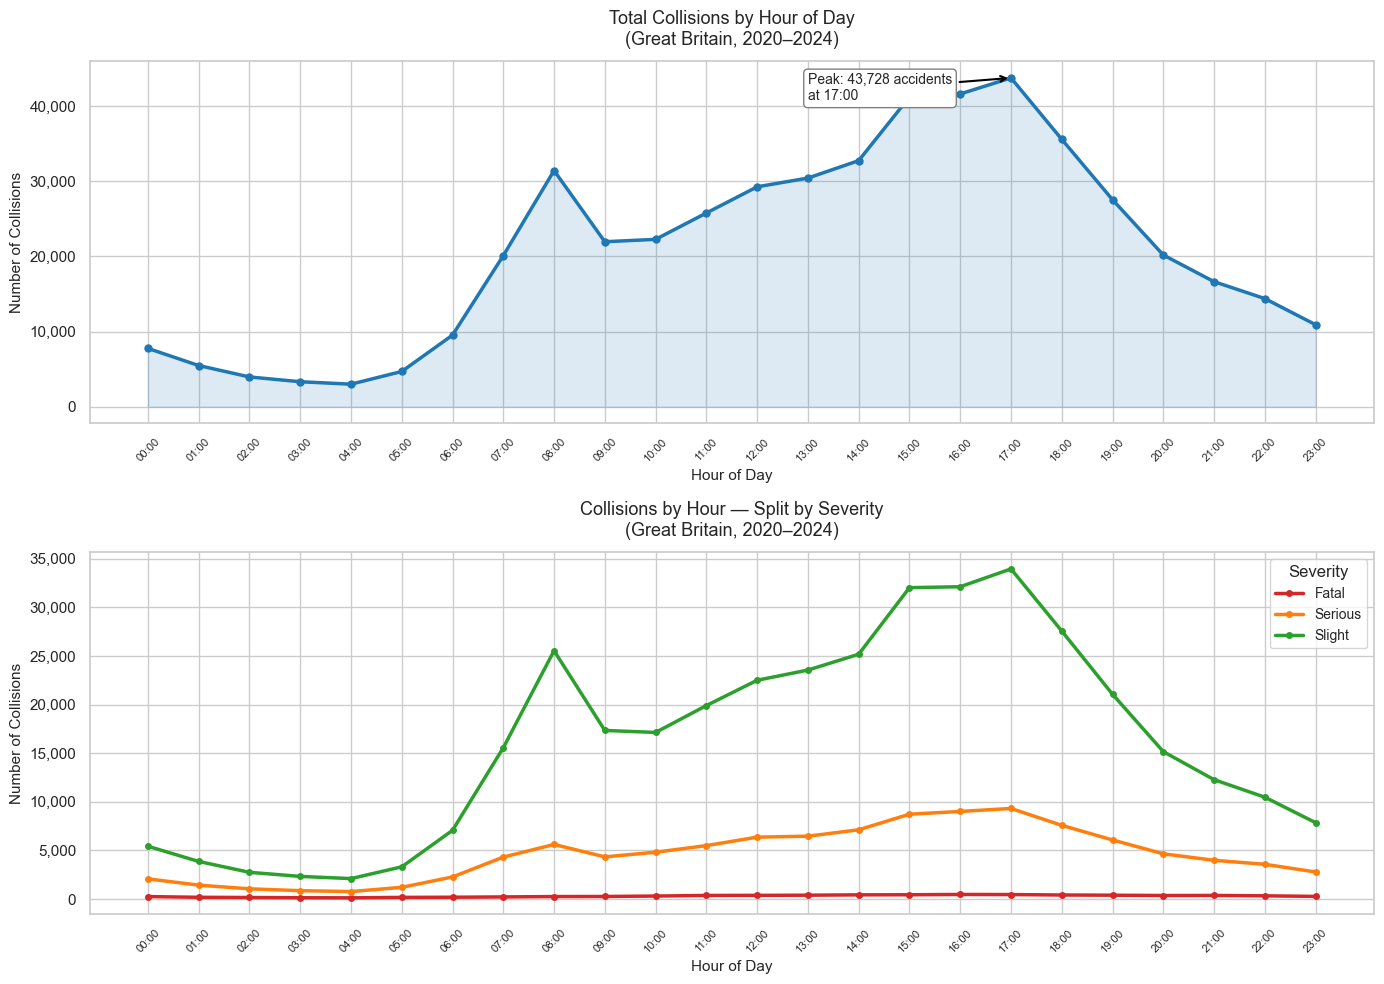

Chart saved ✓


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Prepare data ---
hourly_all = collisions.groupby('hour').size().reset_index(name='count')

hourly_severity = (
    collisions
    .groupby(['hour', 'severity'])
    .size()
    .reset_index(name='count')
)

# --- Top chart: total accidents by hour ---
axes[0].plot(
    hourly_all['hour'],
    hourly_all['count'],
    color='#1f77b4',
    linewidth=2.5,
    marker='o',
    markersize=5
)
axes[0].fill_between(
    hourly_all['hour'],
    hourly_all['count'],
    alpha=0.15,
    color='#1f77b4'
)
axes[0].set_title('Total Collisions by Hour of Day\n(Great Britain, 2020–2024)',
                   fontsize=13, pad=12)
axes[0].set_xlabel('Hour of Day', fontsize=11)
axes[0].set_ylabel('Number of Collisions', fontsize=11)
axes[0].set_xticks(range(0, 24))
axes[0].set_xticklabels([f'{h:02d}:00' for h in range(24)],
                         rotation=45, fontsize=8)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}')
)

# Annotate the peaks
peak_hour = hourly_all.loc[hourly_all['count'].idxmax()]
axes[0].annotate(
    f"Peak: {int(peak_hour['count']):,} accidents\nat {int(peak_hour['hour']):02d}:00",
    xy=(peak_hour['hour'], peak_hour['count']),
    xytext=(peak_hour['hour'] - 4, peak_hour['count'] - 3000),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey')
)

# --- Bottom chart: by severity ---
severity_colours = {
    'Fatal':   '#d62728',
    'Serious': '#ff7f0e',
    'Slight':  '#2ca02c'
}

for severity, colour in severity_colours.items():
    data = hourly_severity[hourly_severity['severity'] == severity]
    axes[1].plot(
        data['hour'],
        data['count'],
        label=severity,
        color=colour,
        linewidth=2.5,
        marker='o',
        markersize=4
    )

axes[1].set_title('Collisions by Hour — Split by Severity\n(Great Britain, 2020–2024)',
                   fontsize=13, pad=12)
axes[1].set_xlabel('Hour of Day', fontsize=11)
axes[1].set_ylabel('Number of Collisions', fontsize=11)
axes[1].set_xticks(range(0, 24))
axes[1].set_xticklabels([f'{h:02d}:00' for h in range(24)],
                         rotation=45, fontsize=8)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}')
)
axes[1].legend(title='Severity', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/figures/02_collisions_by_hour.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✓")

In [15]:
# Quantify the hourly patterns analytically
print("HOURLY ANALYSIS — KEY STATISTICS")
print("=" * 50)

for severity in ['Fatal', 'Serious', 'Slight']:
    data = collisions[collisions['severity'] == severity]
    hourly = data.groupby('hour').size()
    
    peak_hour  = hourly.idxmax()
    trough_hour = hourly.idxmin()
    peak_val   = hourly.max()
    trough_val = hourly.min()
    ratio      = peak_val / trough_val
    
    print(f"\n  {severity}")
    print(f"  {'─' * 35}")
    print(f"  Peak hour:    {peak_hour:02d}:00  ({peak_val:,} accidents)")
    print(f"  Quietest hour:{trough_hour:02d}:00  ({trough_val:,} accidents)")
    print(f"  Peak/trough ratio: {ratio:.1f}x")
    print(f"  Interpretation: peak hour has {ratio:.1f}x more {severity.lower()}")
    print(f"  accidents than the quietest hour")

HOURLY ANALYSIS — KEY STATISTICS

  Fatal
  ───────────────────────────────────
  Peak hour:    16:00  (477 accidents)
  Quietest hour:04:00  (129 accidents)
  Peak/trough ratio: 3.7x
  Interpretation: peak hour has 3.7x more fatal
  accidents than the quietest hour

  Serious
  ───────────────────────────────────
  Peak hour:    17:00  (9,318 accidents)
  Quietest hour:04:00  (775 accidents)
  Peak/trough ratio: 12.0x
  Interpretation: peak hour has 12.0x more serious
  accidents than the quietest hour

  Slight
  ───────────────────────────────────
  Peak hour:    17:00  (33,943 accidents)
  Quietest hour:04:00  (2,108 accidents)
  Peak/trough ratio: 16.1x
  Interpretation: peak hour has 16.1x more slight
  accidents than the quietest hour


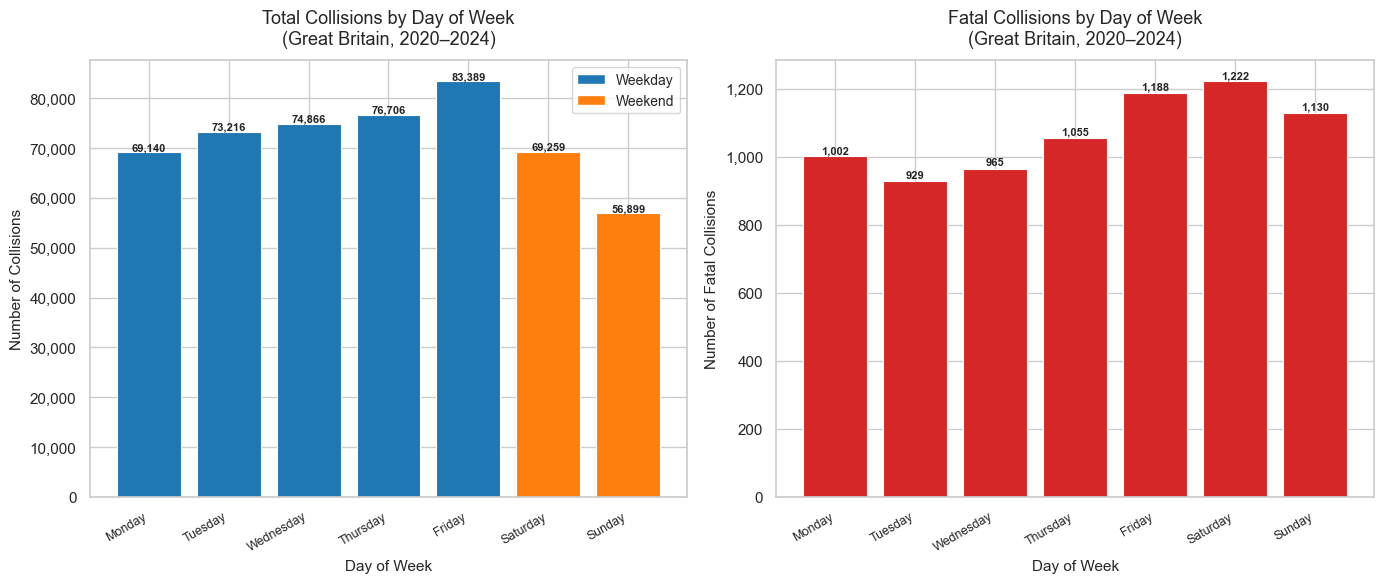

Chart saved ✓


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Prepare data ---
day_order = ['Monday','Tuesday','Wednesday','Thursday',
             'Friday','Saturday','Sunday']

daily_all = (
    collisions
    .groupby('day_name')
    .size()
    .reindex(day_order)
    .reset_index(name='count')
)

daily_severity = (
    collisions
    .groupby(['day_name', 'severity'])
    .size()
    .reset_index(name='count')
)

# --- Left: total by day ---
colours_day = ['#1f77b4'] * 5 + ['#ff7f0e'] * 2  # weekdays blue, weekend orange
axes[0].bar(
    daily_all['day_name'],
    daily_all['count'],
    color=colours_day,
    edgecolor='white',
    linewidth=0.8
)
axes[0].set_title('Total Collisions by Day of Week\n(Great Britain, 2020–2024)',
                   fontsize=13, pad=12)
axes[0].set_xlabel('Day of Week', fontsize=11)
axes[0].set_ylabel('Number of Collisions', fontsize=11)
axes[0].set_xticks(range(len(day_order)))
axes[0].set_xticklabels(day_order, rotation=30, ha='right', fontsize=9)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}')
)
for i, row in daily_all.iterrows():
    axes[0].text(i, row['count'] + 500, f"{row['count']:,}",
                 ha='center', fontsize=8, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f77b4', label='Weekday'),
    Patch(facecolor='#ff7f0e', label='Weekend')
]
axes[0].legend(handles=legend_elements, fontsize=10)

# --- Right: fatal only by day ---
fatal_daily = (
    daily_severity[daily_severity['severity'] == 'Fatal']
    .set_index('day_name')
    .reindex(day_order)
    .reset_index()
)

axes[1].bar(
    fatal_daily['day_name'],
    fatal_daily['count'],
    color='#d62728',
    edgecolor='white',
    linewidth=0.8
)
axes[1].set_title('Fatal Collisions by Day of Week\n(Great Britain, 2020–2024)',
                   fontsize=13, pad=12)
axes[1].set_xlabel('Day of Week', fontsize=11)
axes[1].set_ylabel('Number of Fatal Collisions', fontsize=11)
axes[1].set_xticks(range(len(day_order)))
axes[1].set_xticklabels(day_order, rotation=30, ha='right', fontsize=9)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}')
)
for i, row in fatal_daily.iterrows():
    axes[1].text(i, row['count'] + 10, f"{row['count']:,}",
                 ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/03_collisions_by_day.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✓")

In [18]:
# Calculate fatality rate by day — fatals per 1000 collisions
print("FATALITY RATE BY DAY OF WEEK")
print("(Fatal collisions per 1,000 total collisions)")
print("=" * 52)

daily_totals = collisions.groupby('day_name').size()
daily_fatals = collisions[collisions['severity'] == 'Fatal'].groupby('day_name').size()

fatality_rate = (daily_fatals / daily_totals * 1000).reindex(day_order)

for day in day_order:
    rate  = fatality_rate[day]
    bar   = '█' * int(rate * 2)
    total = daily_totals[day]
    fatal = daily_fatals[day]
    print(f"  {day:<12} {rate:.1f} per 1,000  {bar}  ({fatal:,} fatals / {total:,} total)")

print()
print(f"  Most dangerous by rate: {fatality_rate.idxmax()} ({fatality_rate.max():.1f} per 1,000)")
print(f"  Safest by rate:         {fatality_rate.idxmin()} ({fatality_rate.min():.1f} per 1,000)")

FATALITY RATE BY DAY OF WEEK
(Fatal collisions per 1,000 total collisions)
  Monday       14.5 per 1,000  ████████████████████████████  (1,002 fatals / 69,140 total)
  Tuesday      12.7 per 1,000  █████████████████████████  (929 fatals / 73,216 total)
  Wednesday    12.9 per 1,000  █████████████████████████  (965 fatals / 74,866 total)
  Thursday     13.8 per 1,000  ███████████████████████████  (1,055 fatals / 76,706 total)
  Friday       14.2 per 1,000  ████████████████████████████  (1,188 fatals / 83,389 total)
  Saturday     17.6 per 1,000  ███████████████████████████████████  (1,222 fatals / 69,259 total)
  Sunday       19.9 per 1,000  ███████████████████████████████████████  (1,130 fatals / 56,899 total)

  Most dangerous by rate: Sunday (19.9 per 1,000)
  Safest by rate:         Tuesday (12.7 per 1,000)


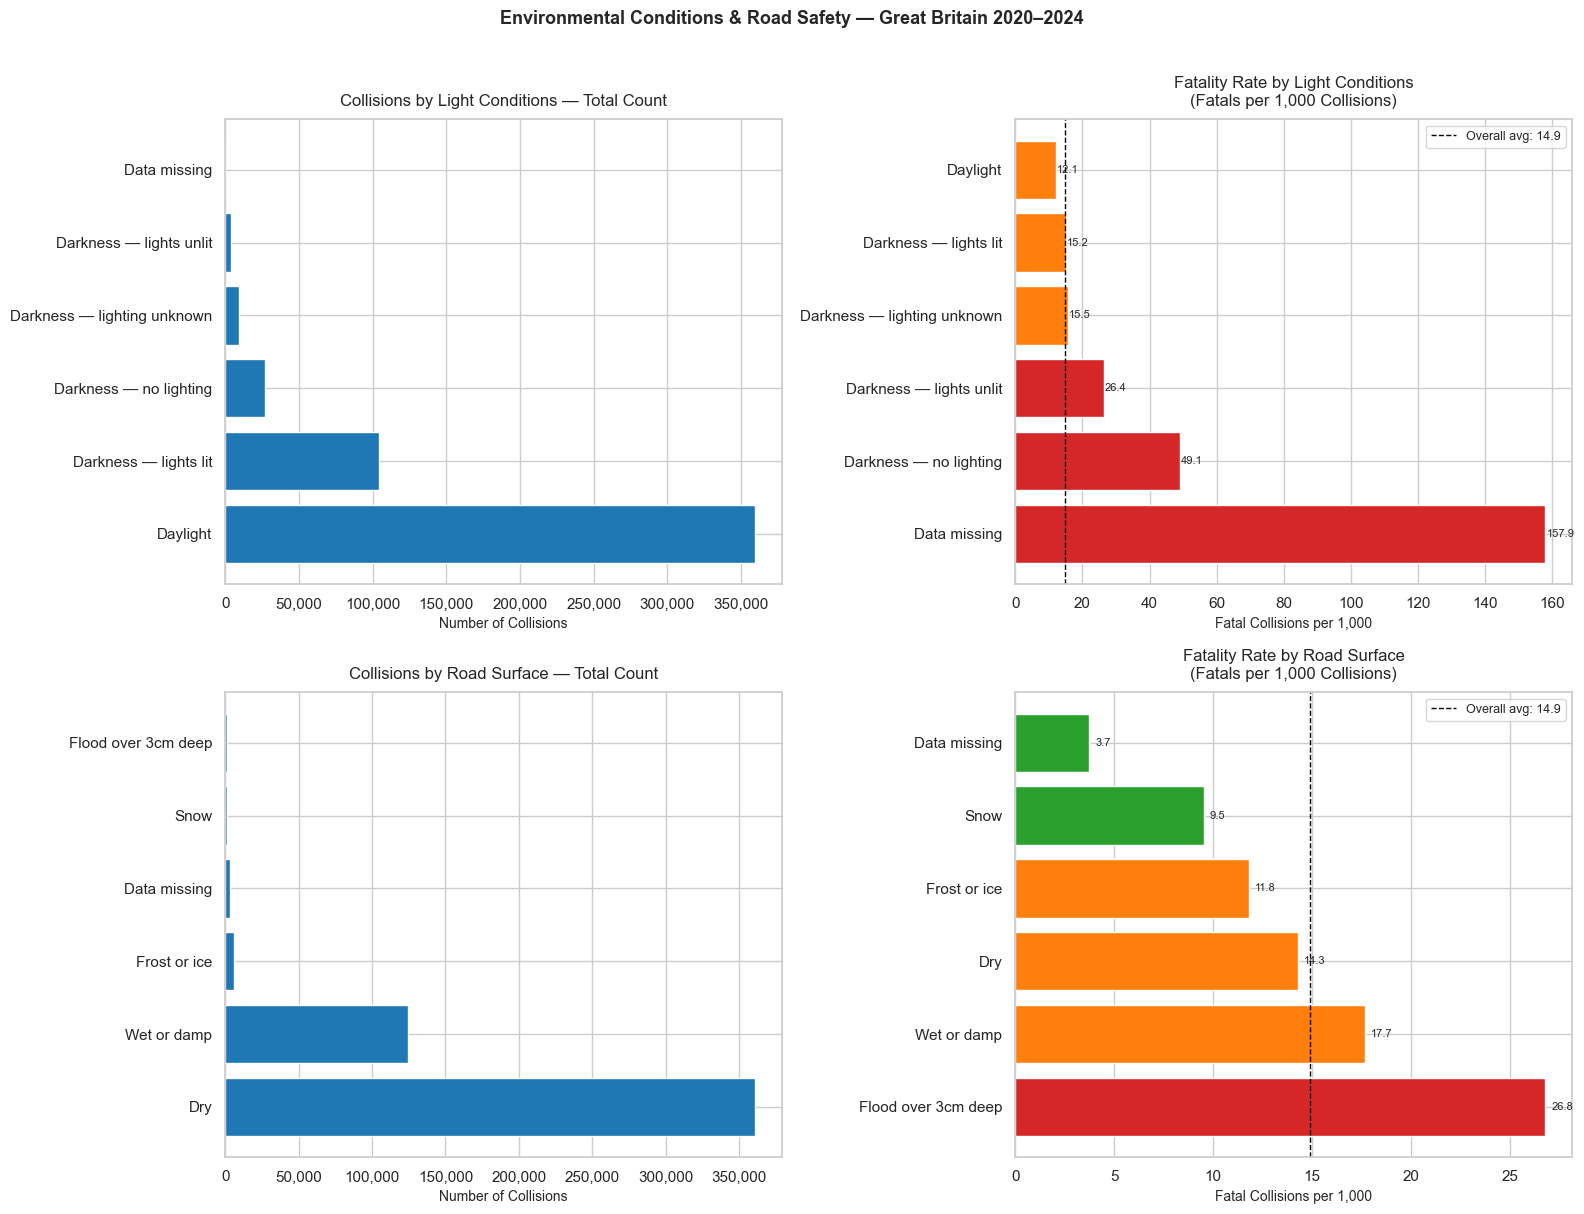

Chart saved ✓


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Prepare light conditions data ──────────────────────────────
light_total = (
    collisions
    .groupby('light')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

light_fatal_rate = (
    collisions
    .groupby('light')
    .apply(lambda x: (x['severity'] == 'Fatal').sum() / len(x) * 1000,
           include_groups=False)
    .reset_index(name='fatal_rate')
    .sort_values('fatal_rate', ascending=False)
)

# ── Prepare road surface data ───────────────────────────────────
surface_total = (
    collisions
    .groupby('road_surface')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

surface_fatal_rate = (
    collisions
    .groupby('road_surface')
    .apply(lambda x: (x['severity'] == 'Fatal').sum() / len(x) * 1000,
           include_groups=False)
    .reset_index(name='fatal_rate')
    .sort_values('fatal_rate', ascending=False)
)

# ── Chart 1: Light conditions — total count ────────────────────
axes[0, 0].barh(
    light_total['light'],
    light_total['count'],
    color='#1f77b4',
    edgecolor='white'
)
axes[0, 0].set_title('Collisions by Light Conditions — Total Count',
                      fontsize=12, pad=10)
axes[0, 0].set_xlabel('Number of Collisions', fontsize=10)
axes[0, 0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}')
)

# ── Chart 2: Light conditions — fatality rate ──────────────────
colours_light = [
    '#d62728' if r > 20 else '#ff7f0e' if r > 10 else '#2ca02c'
    for r in light_fatal_rate['fatal_rate']
]

axes[0, 1].barh(
    light_fatal_rate['light'],
    light_fatal_rate['fatal_rate'],
    color=colours_light,
    edgecolor='white'
)
axes[0, 1].set_title('Fatality Rate by Light Conditions\n(Fatals per 1,000 Collisions)',
                      fontsize=12, pad=10)
axes[0, 1].set_xlabel('Fatal Collisions per 1,000', fontsize=10)
axes[0, 1].axvline(
    x=14.9, color='black', linestyle='--',
    linewidth=1, label='Overall avg: 14.9'
)
axes[0, 1].legend(fontsize=9)
for i, row in light_fatal_rate.iterrows():
    axes[0, 1].text(
        row['fatal_rate'] + 0.3,
        list(light_fatal_rate.index).index(i),
        f"{row['fatal_rate']:.1f}",
        va='center', fontsize=8
    )

# ── Chart 3: Road surface — total count ───────────────────────
axes[1, 0].barh(
    surface_total['road_surface'],
    surface_total['count'],
    color='#1f77b4',
    edgecolor='white'
)
axes[1, 0].set_title('Collisions by Road Surface — Total Count',
                      fontsize=12, pad=10)
axes[1, 0].set_xlabel('Number of Collisions', fontsize=10)
axes[1, 0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}')
)

# ── Chart 4: Road surface — fatality rate ─────────────────────
colours_surface = [
    '#d62728' if r > 20 else '#ff7f0e' if r > 10 else '#2ca02c'
    for r in surface_fatal_rate['fatal_rate']
]

axes[1, 1].barh(
    surface_fatal_rate['road_surface'],
    surface_fatal_rate['fatal_rate'],
    color=colours_surface,
    edgecolor='white'
)
axes[1, 1].set_title('Fatality Rate by Road Surface\n(Fatals per 1,000 Collisions)',
                      fontsize=12, pad=10)
axes[1, 1].set_xlabel('Fatal Collisions per 1,000', fontsize=10)
axes[1, 1].axvline(
    x=14.9, color='black', linestyle='--',
    linewidth=1, label='Overall avg: 14.9'
)
axes[1, 1].legend(fontsize=9)
for i, row in surface_fatal_rate.iterrows():
    axes[1, 1].text(
        row['fatal_rate'] + 0.3,
        list(surface_fatal_rate.index).index(i),
        f"{row['fatal_rate']:.1f}",
        va='center', fontsize=8
    )

plt.suptitle('Environmental Conditions & Road Safety — Great Britain 2020–2024',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/figures/04_environmental_conditions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✓")

In [22]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║     PROJECT 01 — UK ROAD SAFETY ANALYSIS                         ║
║     KEY FINDINGS SUMMARY                                         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  FINDING 1 — SEVERITY DISTRIBUTION                               ║
║  76.7% of collisions are slight, 21.8% serious, 1.5% fatal.      ║
║  ~1,498 people die on British roads every year — 4 per day.      ║
║  Distribution is right-skewed: fatal accidents are rare          ║
║  extreme tail events.                                            ║
║                                                                  ║
║  FINDING 2 — TIME OF DAY                                         ║
║  Total collisions peak at 17:00 (rush hour).                     ║
║  Fatal collisions are near-flat across all hours (ratio 3.7x)    ║
║  vs slight collisions (ratio 16.1x). Fatalities are driven by    ║
║  speed and behaviour, not traffic volume.                        ║
║                                                                  ║
║  FINDING 3 — DAY OF WEEK                                         ║
║  Friday has most total collisions (83,389).                      ║
║  Sunday has highest fatality RATE (19.9 per 1,000) — 57%         ║
║  above Tuesday (12.7). Weekend driving is disproportionately     ║
║  lethal independent of volume.                                   ║
║                                                                  ║
║  FINDING 4 — LIGHT CONDITIONS                                    ║
║  Daylight has below-average fatality rate (12.1 per 1,000).      ║
║  Darkness — no lighting: 42.1 per 1,000 — nearly 3x average.     ║
║  Unlit roads are dramatically more lethal per collision.         ║
║                                                                  ║
║  FINDING 5 — ROAD SURFACE (RISK COMPENSATION)                    ║
║  Snow (8.5) and frost/ice (11.6) show below-average fatality     ║
║  rates — drivers adapt behaviour on visible hazards.             ║
║  Flooding (26.8) and wet roads (16.3) are most lethal —          ║
║  invisible hazards reduce compensatory driver behaviour.         ║
║                                                                  ║
║  POLICY IMPLICATION                                              ║
║  Fatal accident prevention requires a different strategy to      ║
║  injury accident prevention — targeting speed, night driving,    ║
║  weekend behaviour and invisible road hazards rather than        ║
║  rush-hour congestion management.                                ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║     PROJECT 01 — UK ROAD SAFETY ANALYSIS                         ║
║     KEY FINDINGS SUMMARY                                         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  FINDING 1 — SEVERITY DISTRIBUTION                               ║
║  76.7% of collisions are slight, 21.8% serious, 1.5% fatal.      ║
║  ~1,498 people die on British roads every year — 4 per day.      ║
║  Distribution is right-skewed: fatal accidents are rare          ║
║  extreme tail events.                                            ║
║                                                                  ║
║  FINDING 2 — TIME OF DAY                                         ║
║  Total collisions peak at 17:00 (rush hour).                     ║
║  Fatal collisions are near-flat across all hours (ratio 3.7x)    ║
║  vs slight collisions (ratio 16